# Wilma — Exploratory Data Analysis

Look at the training data before we train models.
Run cells top-to-bottom with Shift+Enter.

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

DATA_DIR = Path.cwd().parent / "data" / "processed" if Path.cwd().name == "notebooks" else Path("data") / "processed"

train = pd.read_csv(DATA_DIR / "wilma_v1_train.csv")
val   = pd.read_csv(DATA_DIR / "wilma_v1_val.csv")
test  = pd.read_csv(DATA_DIR / "wilma_v1_test.csv")

print(f"train: {len(train):>6} rows")
print(f"val:   {len(val):>6} rows")
print(f"test:  {len(test):>6} rows")
train.head()

Matplotlib is building the font cache; this may take a moment.


train:  31572 rows
val:     3946 rows
test:    3947 rows


,id,text,label,category,source,language,char_len,raw_hash
0,enron_spam_e753dadd8a19d717,re : equistar deal tickets what is going on ab...,legitimate,legitimate,enron_spam,en,1738,e753dadd8a19d717a1b0fe8340661e9b6aa46190
1,enron_spam_f5f9ccdb44dc37a6,northeast spring membership mixer > february 2...,legitimate,legitimate,enron_spam,en,150,f5f9ccdb44dc37a6a71b0175ef7aeb9d3747773b
2,enron_spam_fb7a8426ab30203c,"enron nominations for november 8 , 2000 ( see ...",legitimate,legitimate,enron_spam,en,97,fb7a8426ab30203cdf79051ae0c5bb87d2f37ed1
3,enron_spam_0930eaffa000882c,"moore medz hello , welcome to medzonline sho a...",scam,scam_other,enron_spam,en,459,0930eaffa000882cb1cf1c179933b6d1deafe70b
4,enron_spam_9f6287c6d5b57ff2,v - i - a - g - r - a is lousy ? ? ? xta 3 hk ...,scam,scam_other,enron_spam,en,835,9f6287c6d5b57ff268750832c60e9805e09b3933


## 2. Class balance

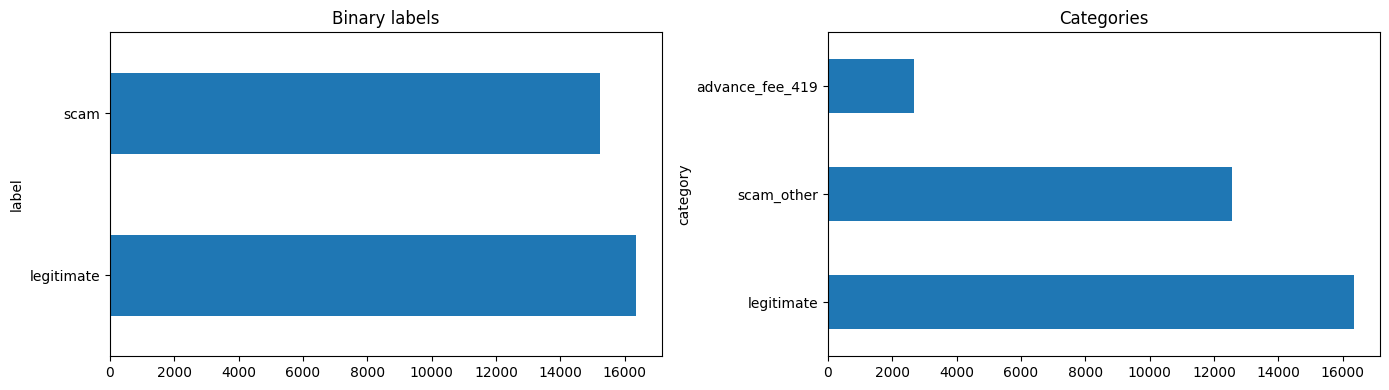

label
legitimate    51.76
scam          48.24
Name: proportion, dtype: float64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train["label"].value_counts().plot.barh(ax=axes[0], title="Binary labels")
train["category"].value_counts().plot.barh(ax=axes[1], title="Categories")
plt.tight_layout()
plt.show()
print((train["label"].value_counts(normalize=True) * 100).round(2))

## 3. Where the data comes from

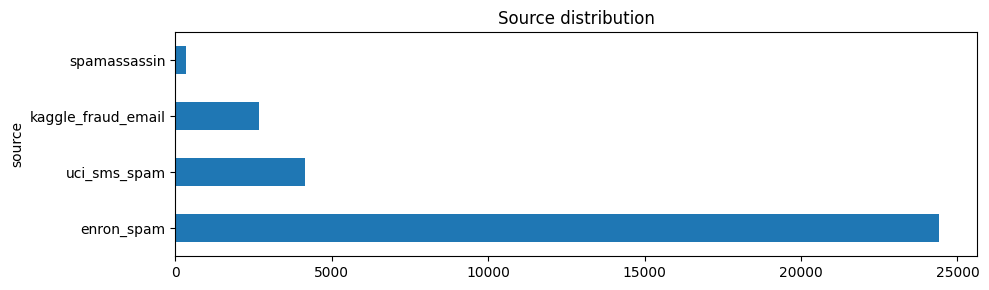

label               legitimate   scam
source                               
enron_spam               12716  11683
kaggle_fraud_email           0   2661
spamassassin                 0    358
uci_sms_spam              3625    529


In [3]:
train["source"].value_counts().plot.barh(figsize=(10, 3), title="Source distribution")
plt.tight_layout()
plt.show()
print(train.groupby("source")["label"].value_counts().unstack(fill_value=0))

## 4. Message length

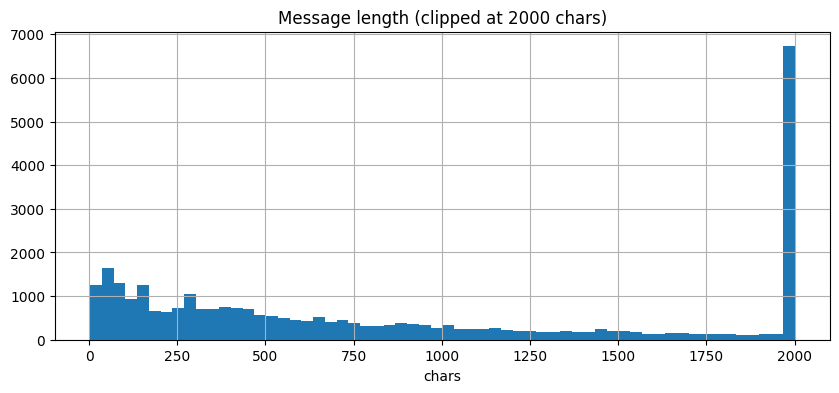

            count  mean   std  min  25%  50%   75%     max
label                                                     
legitimate  16341  1284  4896    3  132  500  1356  229777
scam        15231  1521  2463    4  372  818  2146  129451


In [4]:
train["char_len"].clip(upper=2000).hist(bins=60, figsize=(10, 4))
plt.title("Message length (clipped at 2000 chars)")
plt.xlabel("chars")
plt.show()
print(train.groupby("label")["char_len"].describe().astype(int))

## 5. Languages

In [5]:
print(train["language"].value_counts().head(10))
print(f"\n% English: {(train['language']=='en').mean()*100:.1f}%")

language
en    30582
es      113
fr      110
ca       93
pt       73
nl       65
de       64
af       58
cy       43
it       40
Name: count, dtype: int64

% English: 96.9%


## 6. Words that scream 'scam'

Which words appear way more in scams than in legitimate messages?

In [6]:
import re

def tokenize(text):
    return re.findall(r"[a-zA-Z<>]+", str(text).lower())

scam_counts, legit_counts = Counter(), Counter()
for _, row in train.iterrows():
    bag = scam_counts if row["label"] == "scam" else legit_counts
    bag.update(tokenize(row["text"]))

total_scam = sum(scam_counts.values())
total_legit = sum(legit_counts.values())
scores = []
for w in set(scam_counts) | set(legit_counts):
    if scam_counts[w] + legit_counts[w] >= 50:
        s = scam_counts[w] / total_scam
        l = legit_counts[w] / total_legit
        scores.append((w, np.log((s + 1e-10) / (l + 1e-10)), scam_counts[w], legit_counts[w]))

scores.sort(key=lambda x: x[1], reverse=True)
print("Top 20 scam-leaning words:")
for w, score, sc, lc in scores[:20]:
    print(f"  {w:20s}  log-odds={score:+.2f}   scam={sc:>6}  legit={lc:>6}")

Top 20 scam-leaning words:
  foreigner             log-odds=+15.29   scam=  1606  legit=     0
  pills                 log-odds=+15.08   scam=  1305  legit=     0
  viagra                log-odds=+14.93   scam=  1117  legit=     0
  cialis                log-odds=+14.66   scam=   853  legit=     0
  unclaimed             log-odds=+14.62   scam=   820  legit=     0
  voip                  log-odds=+14.48   scam=   711  legit=     0
  nbsp                  log-odds=+14.47   scam=   707  legit=     0
  computron             log-odds=+14.45   scam=   691  legit=     0
  wysak                 log-odds=+14.27   scam=   580  legit=     0
  abidjan               log-odds=+14.17   scam=   523  legit=     0
  ooking                log-odds=+14.17   scam=   522  legit=     0
  href                  log-odds=+14.05   scam=   465  legit=     0
  zimbabwe              log-odds=+14.02   scam=   452  legit=     0
  wiil                  log-odds=+14.02   scam=   449  legit=     0
  ivoire             

## 7. Data leakage check

Make sure no rows leak between train/val/test.

In [7]:
train_h, val_h, test_h = set(train["raw_hash"]), set(val["raw_hash"]), set(test["raw_hash"])
print(f"train ∩ val:  {len(train_h & val_h)}")
print(f"train ∩ test: {len(train_h & test_h)}")
print(f"val ∩ test:   {len(val_h & test_h)}")
print("\nAll zeros = no leakage")

train ∩ val:  0
train ∩ test: 0
val ∩ test:   0

All zeros = no leakage
